In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Loading Data & Training KNN")

# 1. Load Data saved from Part 4
data_dir = "../DATA/classical_ml"
X_train = np.load(f"{data_dir}/features_train.npy")
y_train = np.load(f"{data_dir}/y_train.npy")
X_val = np.load(f"{data_dir}/features_val.npy")
y_val = np.load(f"{data_dir}/y_val.npy")

# Dictionary to store results for the final deliverable table
results = {}

# 2. Train KNN with k in {1, 3, 5, 7}
best_k = 0
best_knn_val_acc = 0
best_knn_model = None
knn_train_times = {}

for k in [1, 3, 5, 7]:
    start_time = time.time()
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    val_preds = knn.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)
    
    knn_train_times[k] = train_time
    print(f"KNN (k={k}): Val Acc = {val_acc:.4f}, Train Time = {train_time:.4f}s")
    
    if val_acc > best_knn_val_acc:
        best_knn_val_acc = val_acc
        best_k = k
        best_knn_model = knn

print(f"\n Best KNN is k={best_k} with Val Acc: {best_knn_val_acc:.4f}")

# Save metrics and model
inf_start = time.time()
best_knn_preds = best_knn_model.predict(X_val)
inf_time = time.time() - inf_start

results['KNN'] = {
    'Accuracy': accuracy_score(y_val, best_knn_preds),
    'Macro F1': f1_score(y_val, best_knn_preds, average='macro'),
    'Inference Time (s)': inf_time
}
joblib.dump(best_knn_model, f"{data_dir}/best_knn.pkl")

Loading Data & Training KNN
KNN (k=1): Val Acc = 0.9984, Train Time = 0.0096s
KNN (k=3): Val Acc = 0.9984, Train Time = 0.0046s
KNN (k=5): Val Acc = 0.9967, Train Time = 0.0045s
KNN (k=7): Val Acc = 0.9984, Train Time = 0.0035s

 Best KNN is k=1 with Val Acc: 0.9984


['../DATA/classical_ml/best_knn.pkl']

In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("Training SVM with Grid Search pls be patient this might take time")

# Define parameter grid requested in PDF
param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.001]},
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]} # Added linear to compare "with and without RBF"
]

svm = SVC(probability=True)

start_time = time.time()
# 5-fold CV as requested
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
train_time = time.time() - start_time

best_svm = grid_search.best_estimator_
print(f"SVM Tuning Done in {train_time:.2f}s")
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate
inf_start = time.time()
svm_preds = best_svm.predict(X_val)
inf_time = time.time() - inf_start

results['SVM'] = {
    'Accuracy': accuracy_score(y_val, svm_preds),
    'Macro F1': f1_score(y_val, svm_preds, average='macro'),
    'Inference Time (s)': inf_time
}
joblib.dump(best_svm, f"{data_dir}/best_svm.pkl")

Training SVM with Grid Search pls be patient this might take time
SVM Tuning Done in 124.55s
Best Parameters: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}


['../DATA/classical_ml/best_svm.pkl']

Training Random Forest & Plotting Feature Importance
RF Tuning Done in 61.68s
Best RF Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


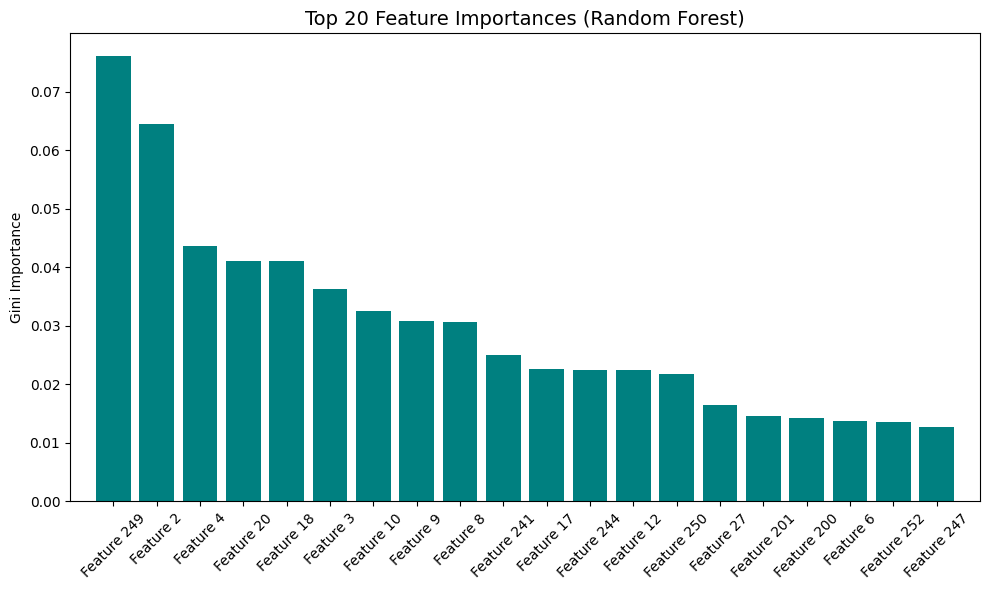

In [3]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Random Forest & Plotting Feature Importance")

rf_params = {'n_estimators': [100, 200, 500], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf = RandomForestClassifier(random_state=42)

start_time = time.time()
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
train_time = time.time() - start_time

best_rf = rf_grid.best_estimator_
print(f"RF Tuning Done in {train_time:.2f}s")
print(f"Best RF Parameters: {rf_grid.best_params_}")

# Evaluate
inf_start = time.time()
rf_preds = best_rf.predict(X_val)
inf_time = time.time() - inf_start

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_val, rf_preds),
    'Macro F1': f1_score(y_val, rf_preds, average='macro'),
    'Inference Time (s)': inf_time
}
joblib.dump(best_rf, f"{data_dir}/best_rf.pkl")

# Plot Deliverable: Feature Importance Plot
# Since we have 240 MFCC + Spectral + LOFAR + DEMON, we plot the top 20
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:20] # Top 20

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (Random Forest)", fontsize=14)
plt.bar(range(20), importances[indices], align="center", color='teal')
plt.xticks(range(20), [f"Feature {i}" for i in indices], rotation=45)
plt.xlim([-1, 20])
plt.ylabel("Gini Importance")
plt.tight_layout()
plt.show()

In [4]:
print("Classical Models Comparison Table")

# Convert results dictionary to DataFrame for nice printing
comparison_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("CLASSICAL MODELS COMPARISON ON VALIDATION SET")
print("="*50)
print(comparison_df.round(4))
print("="*50)

best_model_name = comparison_df['Accuracy'].idxmax()
print(f"\nThe Best Classical Model is: {best_model_name}")
print("Classical ML (Part 5 till comparison table) is 100% COMPLETE, All .pkl files saved.")

Classical Models Comparison Table

CLASSICAL MODELS COMPARISON ON VALIDATION SET
               Accuracy  Macro F1  Inference Time (s)
KNN              0.9984    0.9596              0.0240
SVM              1.0000    1.0000              0.0501
Random Forest    0.9984    0.9713              0.0214

The Best Classical Model is: SVM
Classical ML (Part 5 till comparison table) is 100% COMPLETE, All .pkl files saved.
